# DBSCAN - Density-Based Spatial Clustering of Applications with Noise

## Opis algorytmu

Algorytm DBSCAN ma dwa parametry:
* liczba dodatnia $\varepsilon>0$ - promień 
* liczba naturalna **minPts** liczba punktów w sąsiedztwie

Te dwa parametry definiują **gęste** regiony w przestrzeni zbioru danych. Region jest gęsty, jeśli każde jego otoczenie o promieniu $\varepsilon$ zawiera co najmniej minPts punktów.

Algorytm DBSCAN klasyfikuje punkty danych do jednej z trzech kategorii:
1. **podstawowe punkty** (core points)
2. **punkty brzegowe** (border points) 
3. **wartości odstające** (noise)

Ad 1. $p$ jest punktem podstawowym, jeśli przynajmniej minPts punktów znajduje się w odległości $\varepsilon$ od niego **(włączając $p$)**.

Ad 2. $q$ jest punktem brzegowym, jeśli znajduje się w odległości $ɛ$ od punktu podstawowego $p$, ale sam nie jest podstawowy.

Ad 3. Inne punkty to wartości odstające.

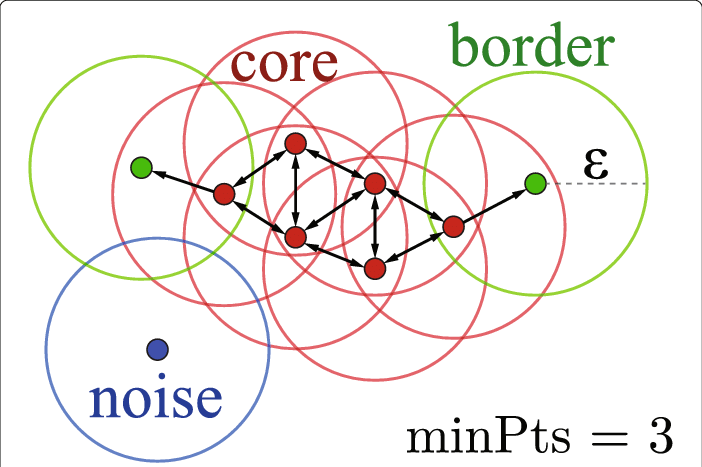

Bezpośrednio z rysunku widać, że 
* algorytm DBSCAN zależy od parametrów $\varepsilon$ i minPts;
* nie trzeba podawać liczby klastrów
* jest odporny na wartości odstające

## DBSCAN w sklearn

Najważniejsze parametry sklearn.cluster.DBSCAN:
1. **eps** ($ɛ>0$) wartość domyślna = 0,5
2. **min_samples** (minPts) wartość domyślna = 5
3. **metric** — metryka. Dopuszczalne wartości to ‘cityblock’, ‘cosine’, **‘euclidean’**, ‘l1’, ‘l2’, ‘manhattan’, ‘braycurtis’, ‘canberra’, ‘chebyshev’, ‘correlation’, ‘dice’, ‘hamming’, ‘jaccard’, ‘kulsinski’, ‘mahalanobis’, ‘minkowski’, ‘rogerstanimoto’, ‘russellrao’, ‘seuclidean’, ‘sokalmichener’, ‘sokalsneath’, ‘sqeuclidean’, ‘yule’

## Model DBSCAN dla blobs

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_biclusters
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import math

In [2]:
n_points = 200
n_dimensions = 2
cluster_centers = 4
cluster_std = 1.2
data, cluster = make_blobs(n_samples=n_points, 
                           n_features=n_dimensions, 
                           centers=cluster_centers, 
                           cluster_std=cluster_std, 
                           random_state=1979)

x,y = data.T

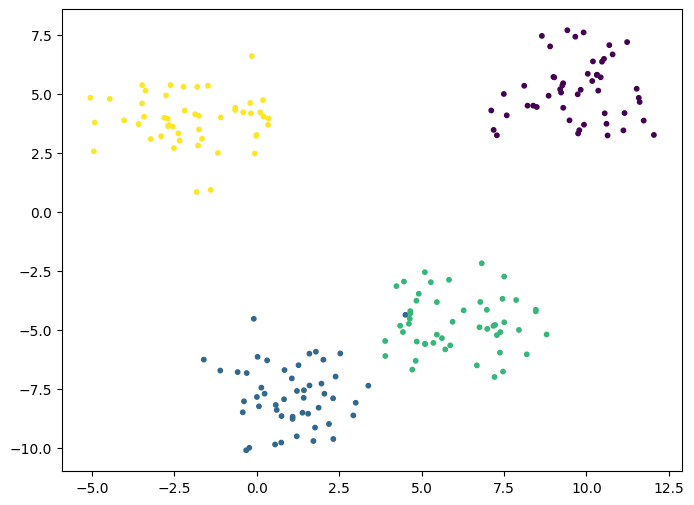

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=cluster, s=10)
plt.show()

In [4]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN()
dbscan.fit(data)

DBSCAN()

Atrybuty DBSCAN() w sklearn

Indeksy punktów podstawowych (core sample indices):

In [5]:
dbscan.core_sample_indices_

array([  1,   4,  12,  18,  25,  26,  33,  41,  59,  68,  72,  76,  78,
        88, 108, 112, 114, 116, 119, 121, 122, 127, 130, 138, 140, 149,
       153, 158, 170, 174, 175, 185, 191, 193, 198], dtype=int64)

Punty podstawowe - ich współrzędne

In [6]:
dbscan.components_

array([[ 9.29104663e+00,  5.44398499e+00],
       [-2.67724874e+00,  3.64569879e+00],
       [ 7.22909320e+00, -4.79574341e+00],
       [ 4.65387933e+00, -4.21017589e+00],
       [ 5.61384320e+00, -5.35379998e+00],
       [ 4.63902509e+00, -4.53094135e+00],
       [ 1.30984565e-03, -7.84592800e+00],
       [ 6.98991782e+00, -4.96322608e+00],
       [ 1.01741129e+01,  5.53723690e+00],
       [ 1.08517170e+00, -8.68107238e+00],
       [ 9.22932252e+00,  5.04927519e+00],
       [ 9.20044968e+00,  5.18361190e+00],
       [ 4.50762939e+00, -4.36482479e+00],
       [-2.38197017e+00,  3.32047029e+00],
       [ 4.34691683e+00, -4.82919208e+00],
       [ 4.61238913e+00, -4.74624048e+00],
       [ 1.00393475e+01,  5.84328105e+00],
       [ 7.38715051e+00, -5.09875792e+00],
       [ 1.03219173e+01,  5.80455817e+00],
       [ 7.28041596e+00, -5.22701281e+00],
       [ 2.01371342e-01,  4.03669688e+00],
       [-4.12211423e-01,  4.21189253e+00],
       [ 5.35434701e+00, -5.55587599e+00],
       [-1.

Etykiety klastrów dla punktów ze zbioru uczącego. Wartości odstające mają etykietę -1.

In [7]:
dbscan.labels_

array([-1,  0, -1,  8,  1, -1, -1, -1, -1, -1, -1, -1,  2, -1, -1, -1, -1,
       -1,  3, -1, -1,  4, -1, -1, -1,  4,  3,  3, -1, -1,  4, -1, -1,  5,
       -1, -1, -1, -1, -1, -1, -1,  2, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  2, -1, -1, -1,  6,  1, -1, -1, -1,  8, -1, -1, -1,
        7, -1, -1, -1,  0, -1,  6,  7,  0, -1,  3, -1, -1,  1, -1, -1,  7,
       -1, -1, -1,  1,  7, -1, -1,  5,  8, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1,  3, -1, -1, -1,  3, -1,  6, -1,  2, -1,  5,
        6, -1,  2,  8,  2, -1, -1,  0,  8, -1, -1,  4,  5,  7, -1, -1, -1,
        8, -1,  8, -1,  1, -1, -1,  3, -1, -1, -1, -1, -1,  1, -1, -1, -1,
        1, -1, -1, -1, -1,  2, -1, -1,  4, -1, -1, -1, -1,  0, -1, -1,  5,
        3,  0, -1, -1,  6,  0,  8, -1, -1, -1, -1, -1, -1,  4,  8,  1, -1,
       -1, -1, -1, -1,  1,  4,  6, -1, -1, -1, -1,  8, -1], dtype=int64)

Liczba zmiennych w zbiorze uczącym

In [8]:
dbscan.n_features_in_

2

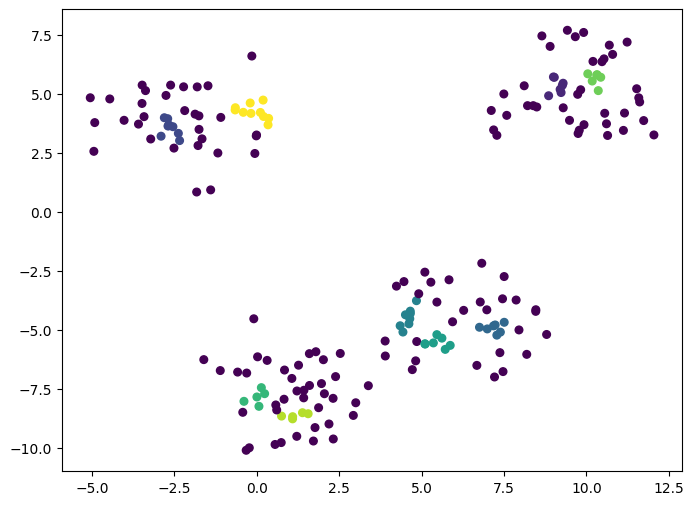

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=dbscan.labels_, s=30)
plt.show()

## Zmieniając $\varepsilon$ i minPts.

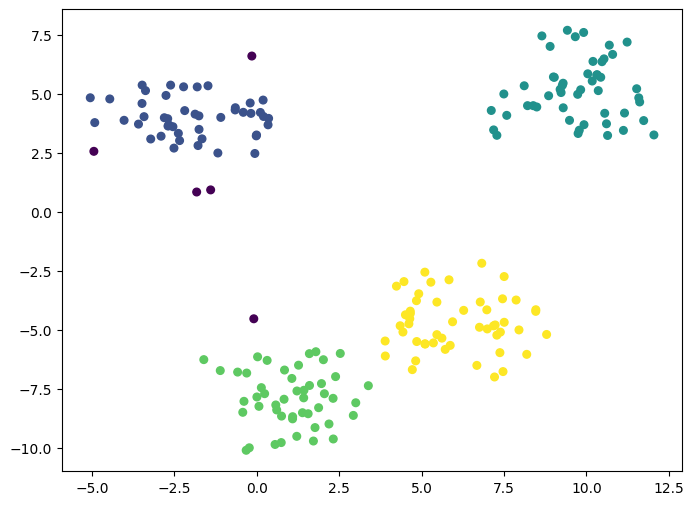

In [10]:
# Zmieńmy parametry
epsilon = 1.1
minPts = 4

dbscan=DBSCAN(eps=epsilon,min_samples=minPts)
dbscan.fit(data)

plt.figure(figsize=(8,6))
plt.scatter(x, y, c=dbscan.labels_, s=30)
plt.show()

## Ustawianie parametrów

**minPts** powinno być $\geq 3$. Rekomenduje się, aby dim+1 $\leq$ minPts $\leq$ 2*dim. 

Gdy minPts jest ustawione, obliczamy $\varepsilon$ według następującej procedury
* dla każdego punktu oblicz odległość do $k$-najbliższych sąsiadów (można do tego celu użyć sklearn.neighbors.NearestNeighbors) dla $k=$minPts.
* znajdź odległość do $k$-tego najbliższego sąsiada.
* Posortuj odległości od najmniejszej do największej wartości
* Narysuj wykres dla posortowane odległości
* znajdź **łokieć**

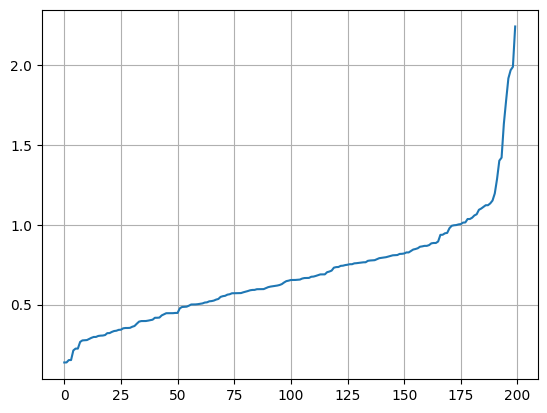

In [11]:
from sklearn.neighbors import NearestNeighbors
minPts = 4
neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(data)
distances, indices = neighbors_fit.kneighbors(data)
dist = distances[:,minPts-1]
dist_sort = np.sort(dist)
plt.plot(dist_sort)
plt.grid(True)
plt.show()

## Przykład z okręgami: K-means vs. DBSCAN

In [12]:
np.random.seed(1978)

In [13]:
def PointsInCircum(r,n=100):
    return [(math.cos(2*math.pi/n*x)*r+np.random.normal(-30,30),math.sin(2*math.pi/n*x)*r+np.random.normal(-30,30)) for x in range(1,n+1)]

def PointsInUHalfCircum(r,n=100):
    return [(math.cos(math.pi/n*x+math.pi)*r+np.random.normal(-30,30),math.sin(math.pi/n*x+math.pi)*r+np.random.normal(-30,30)) for x in range(1,n+1)]

def PointsInDHalfCircum(r,n=100):
    return [(math.cos(math.pi/n*x+math.pi)*r+np.random.normal(-30,30),math.sin(math.pi/n*x+math.pi)*r+np.random.normal(-30,30)) for x in range(1,n+1)]

In [24]:
# Creating data points in the form of a circle
df=pd.DataFrame(PointsInCircum(500,1000))
df=pd.concat([df,pd.DataFrame(PointsInCircum(300,700))])
df=pd.concat([df,pd.DataFrame(PointsInCircum(100,300))])

# Adding noise to the dataset
#df=pd.concat([df,pd.DataFrame([(np.random.randint(-600,600),np.random.randint(-600,600)) 
#                               for i in range(300)])])

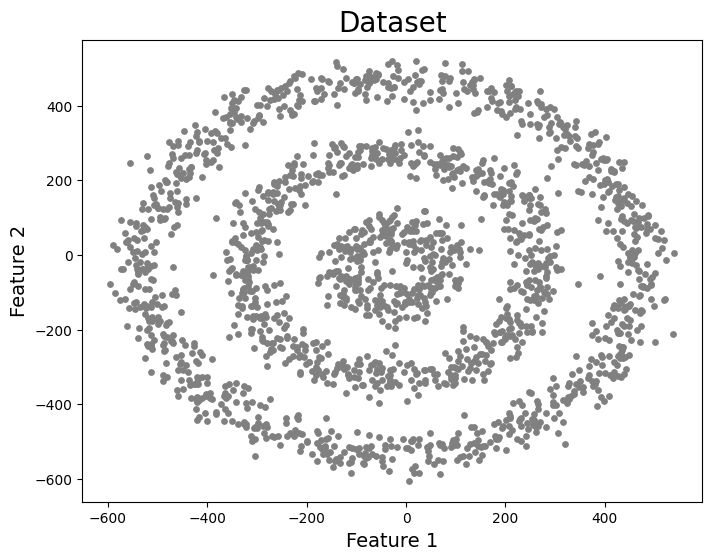

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(df[0],df[1],s=15,color='grey')
plt.title('Dataset',fontsize=20)
plt.xlabel('Feature 1',fontsize=14)
plt.ylabel('Feature 2',fontsize=14)
plt.show()

In [27]:
circles = df.to_numpy()
from sklearn.cluster import KMeans
Kmean = KMeans(n_clusters=3)
Kmean.fit(circles)

KMeans(n_clusters=3)

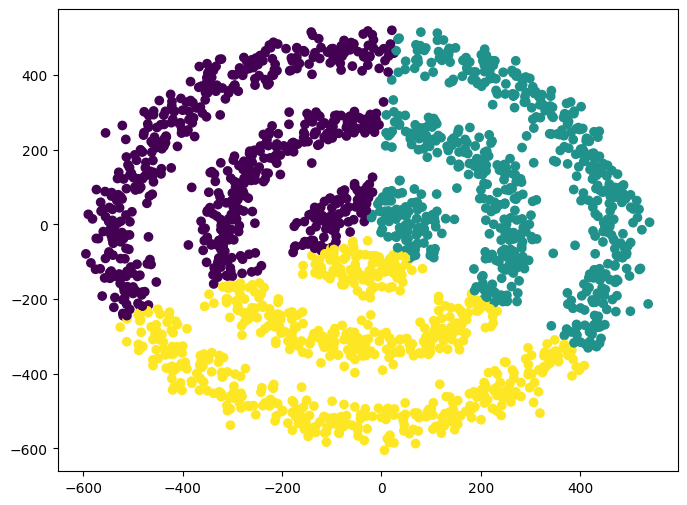

In [28]:
x,y = circles.T
plt.figure(figsize=(8,6))
plt.scatter(x,y,c=Kmean.labels_)
plt.show()


A teraz DBSCAN!

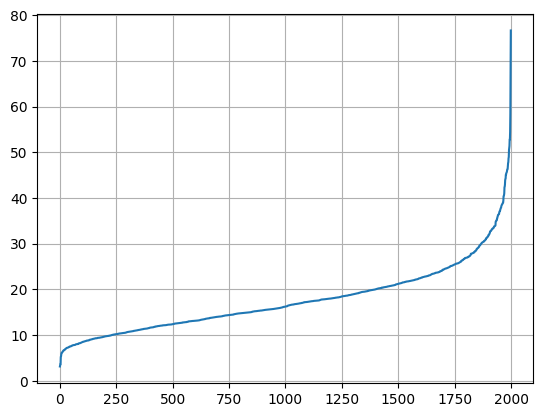

In [29]:
from sklearn.neighbors import NearestNeighbors
minPts = 4
neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(circles)
distances, indices = neighbors_fit.kneighbors(circles)
dist = distances[:,minPts-1]
dist_sort = np.sort(dist)
plt.plot(dist_sort)
plt.grid(True)
plt.show()

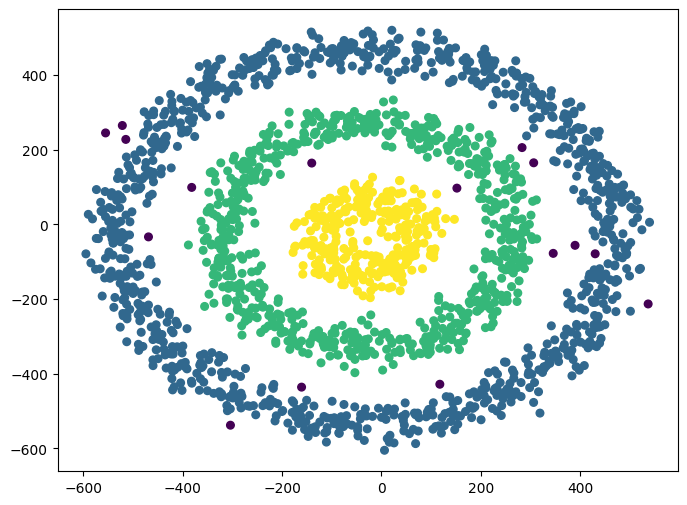

In [30]:
epsilon = 35
minPts = 4

dbscan=DBSCAN(eps=epsilon,min_samples=minPts)
dbscan.fit(circles)

plt.figure(figsize=(8,6))
plt.scatter(x, y, c=dbscan.labels_, s=30)
plt.show()

## Przykład

In [31]:
df = pd.read_csv('mall.csv')

In [32]:
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100)
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40


In [33]:
data = pd.get_dummies(df, columns=['Gender'], drop_first=True)
data.drop(labels=['CustomerID'], axis=1, inplace=True)
data.head()

,Age,Annual Income ($),Spending Score (1-100),Gender_Male
0,19,15000,39,True
1,21,15000,81,True
2,20,16000,6,False
3,23,16000,77,False
4,31,17000,40,False


In [34]:
data.describe()

,Age,Annual Income ($),Spending Score (1-100)
count,204.000000,204.000000,204.000000
mean,38.808824,63504.901961,50.549020
std,13.860946,33503.399952,25.996259
min,18.000000,15000.000000,1.000000
25%,28.750000,42000.000000,34.750000
50%,36.000000,62000.000000,50.000000
75%,49.000000,78000.000000,73.000000
max,70.000000,245000.000000,99.000000


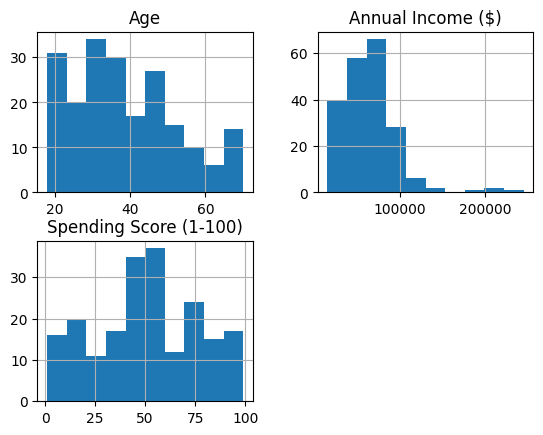

In [35]:
data.hist()
plt.show()

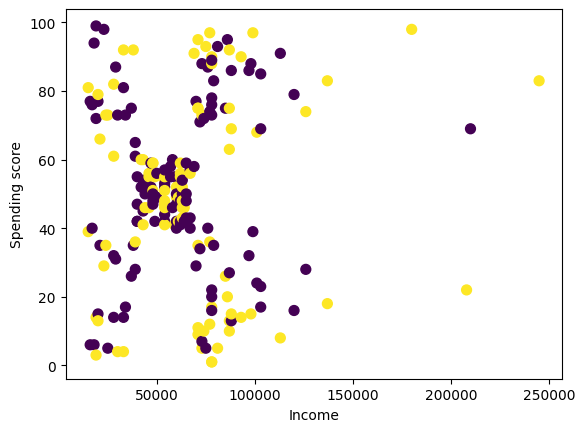

In [36]:
x1,y1 = np.array(data[['Annual Income ($)','Spending Score (1-100)']]).T

plt.scatter(x1, y1, s =50, c=data['Gender_Male'])
plt.xlabel('Income')
plt.ylabel('Spending score')
plt.show()

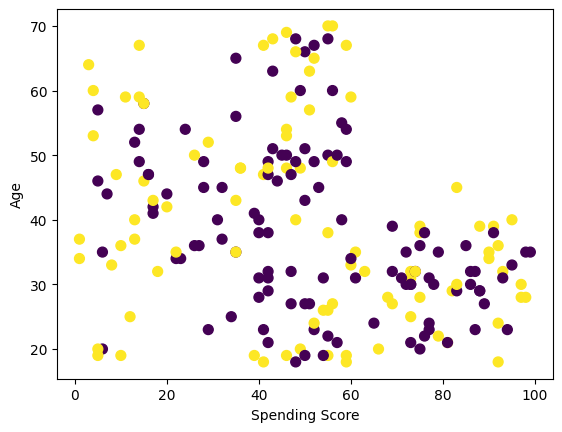

In [37]:
x2,y2 = np.array(data[['Spending Score (1-100)','Age']]).T

plt.scatter(x2, y2, s =50, c=data['Gender_Male'])
plt.xlabel('Spending Score')
plt.ylabel('Age')
plt.show()

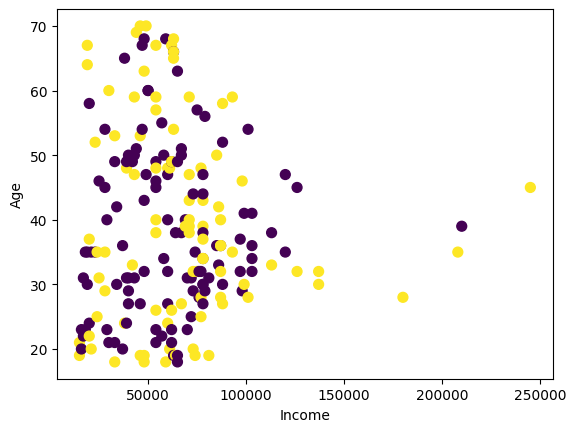

In [38]:
x3,y3 = np.array(data[['Annual Income ($)','Age']]).T

plt.scatter(x3, y3, s =50, c=data['Gender_Male'])
plt.xlabel('Income')
plt.ylabel('Age')
plt.show()

In [39]:
data1 = data.drop(labels=['Gender_Male'], axis=1)


In [40]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
data2 = mms.fit_transform(data1)

In [41]:
from sklearn.preprocessing import scale

data3 = scale(data1, axis=0)

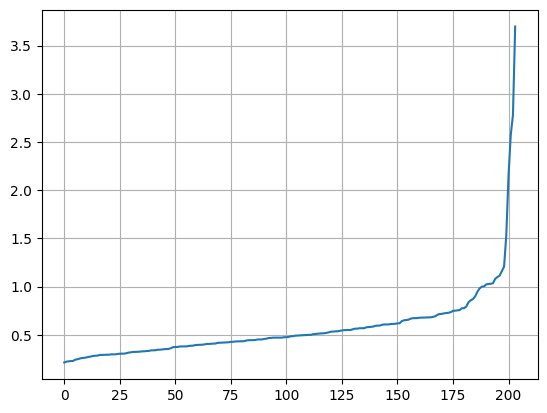

In [42]:
from sklearn.neighbors import NearestNeighbors
minPts = 6
neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(data3)
distances, indices = neighbors_fit.kneighbors(data3)
dist = distances[:,minPts-1]
dist_sort = np.sort(dist)
plt.grid(True)
plt.plot(dist_sort)
plt.show()

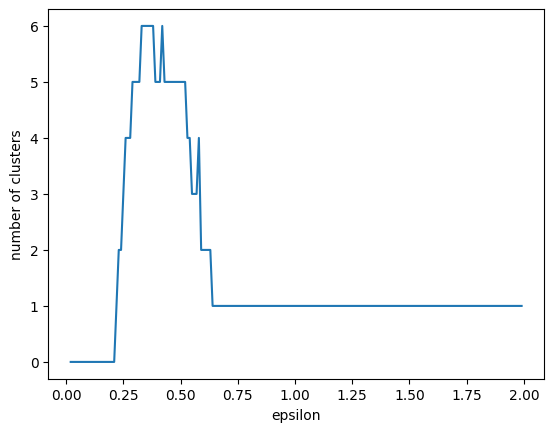

In [43]:
nclusters = []
minPts = 6
for i in range(2, 200):
  dbscan=DBSCAN(eps=i/100,min_samples=minPts)
  dbscan.fit(data3)
  labels = dbscan.labels_
  nclusters.append(np.max(labels)+1)

plt.plot([i/100 for i in range(2,200)],nclusters)
plt.xlabel('epsilon')
plt.ylabel('number of clusters')
plt.show()

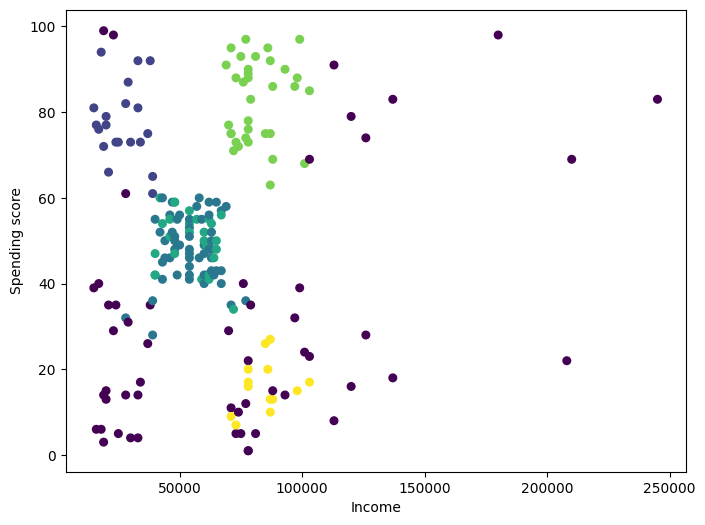

In [44]:
epsilon = 0.52
minPts = 6

dbscan=DBSCAN(eps=epsilon,min_samples=minPts)
dbscan.fit(data3)

plt.figure(figsize=(8,6))
plt.scatter(x1, y1, c=dbscan.labels_, s=30)
plt.xlabel('Income')
plt.ylabel('Spending score')
plt.show()

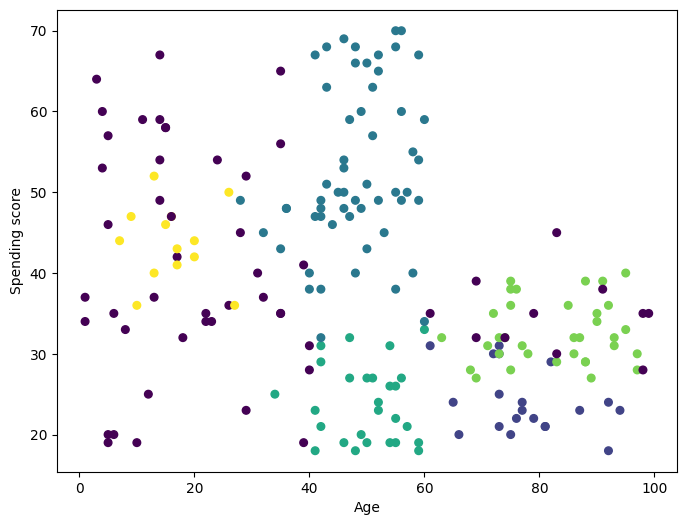

In [45]:
epsilon = 0.52
minPts = 6

dbscan=DBSCAN(eps=epsilon,min_samples=minPts)
dbscan.fit(data3)

plt.figure(figsize=(8,6))
plt.scatter(x2, y2, c=dbscan.labels_, s=30)
plt.xlabel('Age')
plt.ylabel('Spending score')
plt.show()

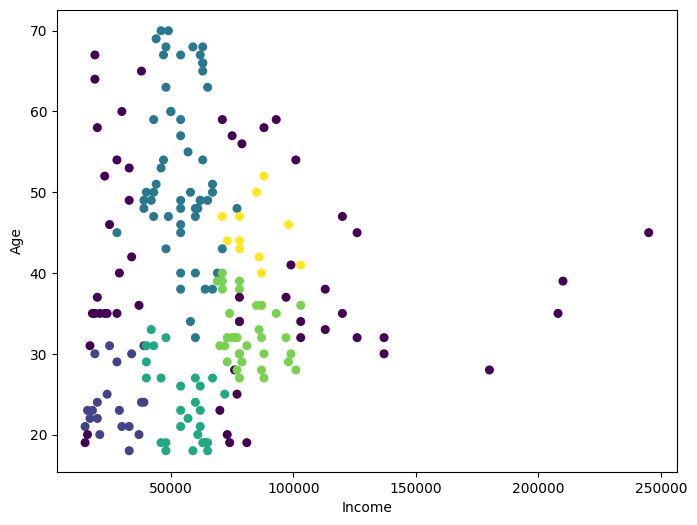

In [46]:
epsilon = 0.52
minPts = 6

dbscan=DBSCAN(eps=epsilon,min_samples=minPts)
dbscan.fit(data3)

plt.figure(figsize=(8,6))
plt.scatter(x3, y3, c=dbscan.labels_, s=30)
plt.xlabel('Income')
plt.ylabel('Age')
plt.show()

In [47]:
cluster =dbscan.labels_
x,y,z = np.array(data[['Age','Annual Income ($)','Spending Score (1-100)']]).T

In [48]:
def format3D(axis, labels=('x', 'y', 'z'), limits=None):
    """3D plot helper function to set labels, pane color, and axis limits"""
    axis.set_xlabel('\n${}$'.format(labels[0]), linespacing=3)
    axis.set_ylabel('\n${}$'.format(labels[1]), linespacing=3)
    axis.set_zlabel('\n${}$'.format(labels[2]), linespacing=3)
    transparent = (1.0, 1.0, 1.0, 0.0)
    axis.w_xaxis.set_pane_color(transparent)
    axis.w_yaxis.set_pane_color(transparent)
    axis.w_zaxis.set_pane_color(transparent)
    if limits:
        axis.set_xlim(limits[0])
        axis.set_ylim(limits[1])
        axis.set_zlim(limits[2])

AttributeError: 'Axes3D' object has no attribute 'w_xaxis'

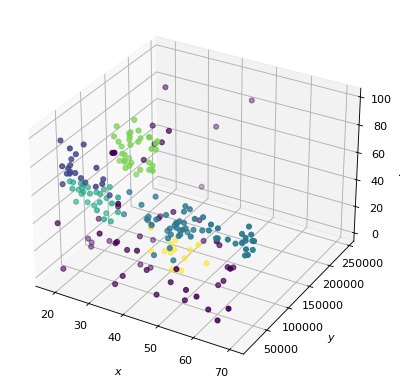

In [49]:
fig = plt.figure(figsize=(8, 6), dpi=80)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=cluster)
format3D(ax)
plt.tight_layout();

## Absenteeism at work

In [50]:
from pandas.io.formats.format import DataFrameFormatter

df = pd.read_csv('Absenteeism_at_work.csv', sep=';')

Attribute Information:

1. Individual identification (ID)
2. Reason for absence (ICD).
Absences attested by the International Code of Diseases (ICD) stratified into 21 categories (I to XXI) as follows:

I Certain infectious and parasitic diseases
II Neoplasms
III Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism
IV Endocrine, nutritional and metabolic diseases
V Mental and behavioural disorders
VI Diseases of the nervous system
VII Diseases of the eye and adnexa
VIII Diseases of the ear and mastoid process
IX Diseases of the circulatory system
X Diseases of the respiratory system
XI Diseases of the digestive system
XII Diseases of the skin and subcutaneous tissue
XIII Diseases of the musculoskeletal system and connective tissue
XIV Diseases of the genitourinary system
XV Pregnancy, childbirth and the puerperium
XVI Certain conditions originating in the perinatal period
XVII Congenital malformations, deformations and chromosomal abnormalities
XVIII Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified
XIX Injury, poisoning and certain other consequences of external causes
XX External causes of morbidity and mortality
XXI Factors influencing health status and contact with health services.

And 7 categories without (CID) patient follow-up (22), medical consultation (23), blood donation (24), laboratory examination (25), unjustified absence (26), physiotherapy (27), dental consultation (28).
3. Month of absence
4. Day of the week (Monday (2), Tuesday (3), Wednesday (4), Thursday (5), Friday (6))
5. Seasons (summer (1), autumn (2), winter (3), spring (4))
6. Transportation expense
7. Distance from Residence to Work (kilometers)
8. Service time
9. Age
10. Work load Average/day
11. Hit target
12. Disciplinary failure (yes=1; no=0)
13. Education (high school (1), graduate (2), postgraduate (3), master and doctor (4))
14. Son (number of children)
15. Social drinker (yes=1; no=0)
16. Social smoker (yes=1; no=0)
17. Pet (number of pet)
18. Weight
19. Height
20. Body mass index
21. Absenteeism time in hours (target)

In [51]:
df.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2


In [52]:
df.describe()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,...,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,18.017568,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,271.490235,...,0.054054,1.291892,1.018919,0.567568,0.072973,0.745946,79.035135,172.114865,26.677027,6.924324
std,11.021247,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,39.058116,...,0.226277,0.673238,1.098489,0.495749,0.260268,1.318258,12.883211,6.034995,4.285452,13.330998
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,205.917000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,244.387000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,264.249000,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,294.217000,...,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,36.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,378.884000,...,1.000000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000


In [53]:
column_list = ['Reason for absence', 'Month of absence', 
                        'Day of the week', 'Seasons', 'Education']
cdf = pd.get_dummies(df, columns=column_list)
cdf = cdf.drop(labels=['ID'], axis=1).astype(np.float64)
cdf.head()

,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,Hit target,Disciplinary failure,Son,Social drinker,Social smoker,...,Day of the week_5,Day of the week_6,Seasons_1,Seasons_2,Seasons_3,Seasons_4,Education_1,Education_2,Education_3,Education_4
0,289.0,36.0,13.0,33.0,239.554,97.0,0.0,2.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,118.0,13.0,18.0,50.0,239.554,97.0,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,179.0,51.0,18.0,38.0,239.554,97.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,279.0,5.0,14.0,39.0,239.554,97.0,0.0,2.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,289.0,36.0,13.0,33.0,239.554,97.0,0.0,2.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [54]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
sdf = ss.fit_transform(cdf)

In [55]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=15, random_state=1000)
data_tsne = tsne.fit_transform(sdf)

df_tsne = pd.DataFrame(data_tsne, columns=['x', 'y'], index=cdf.index) 
dff = pd.concat([cdf, df_tsne], axis=1)

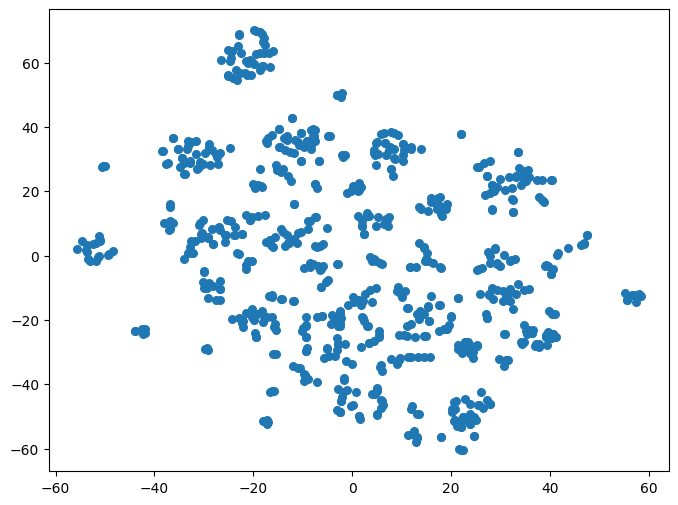

In [56]:
plt.figure(figsize=(8,6))
plt.scatter(df_tsne['x'], df_tsne['y'], s=30)
plt.show()

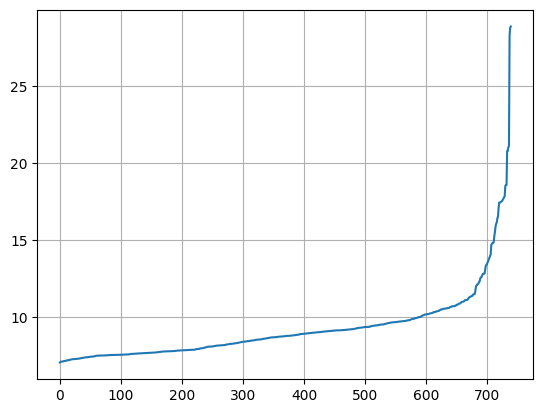

In [63]:
from sklearn.neighbors import NearestNeighbors
minPts = 70
neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(sdf)
distances, indices = neighbors_fit.kneighbors(sdf)
dist = distances[:,minPts-1]
dist_sort = np.sort(dist)
plt.plot(dist_sort)
plt.grid(True)
plt.show()

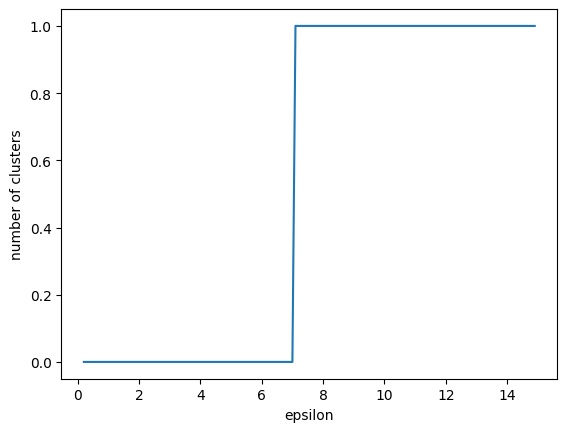

In [62]:
nclusters = []
minPts = 70
for i in range(2, 150):
  dbscan=DBSCAN(eps=i/10,min_samples=minPts)
  dbscan.fit(sdf)
  labels = dbscan.labels_
  nclusters.append(np.max(labels)+1)

plt.plot([i/10 for i in range(2,150)],nclusters)
plt.xlabel('epsilon')
plt.ylabel('number of clusters')
plt.show()

In [61]:
ds = DBSCAN(eps=6, min_samples=10)
Y_pred = ds.fit_predict(sdf)

print('Number of clusters: {}'.format(np.max(Y_pred) + 1))
print('Number of noise points: {}'.format(np.sum(Y_pred==-1)))

Number of clusters: 3
Number of noise points: 391
